In [1]:
import os, sys 
os.getcwd()
os.chdir('/Users/eo/Documents/GitHub/OPTOOLS')
sys.path.append('/Users/eo/Documents/GitHub/OPTOOLS/PYTHON')

import numpy as np 
import pandas as pd 
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from PYTHON.simulator_functions.generator import surface_from_Z1kxky_uniform_phase
from PYTHON.simulator_functions.spectrum_wrappers import def_spectrum_for_surface
from tests.test_surface_simulations import run_case


## Example 1: Gaussian vs. PM Spectra

In this first example, we define the wave spectrum *direcly on the $k_x,k_y$ grid* which is the Fourier transform of the $x-y$ grid we want for the sea surface.

#### Parameters: Use the same for both cases 

In [2]:
params = dict(
    x_grid_points=2048,  # 2048 works but takes awhile
    y_grid_points=2048,
    x_spacing=0.5, y_spacing=0.5,
    mean_direction_degrees=50.0,
    local_depth=100.0,
    wave_period=10.0,
    significant_wave_height=4.0,
    seed=100
)

#### Run Gaussian case

σ = 1.000 m,  max|ζ| = 1.981 m,  max/σ = 1.98


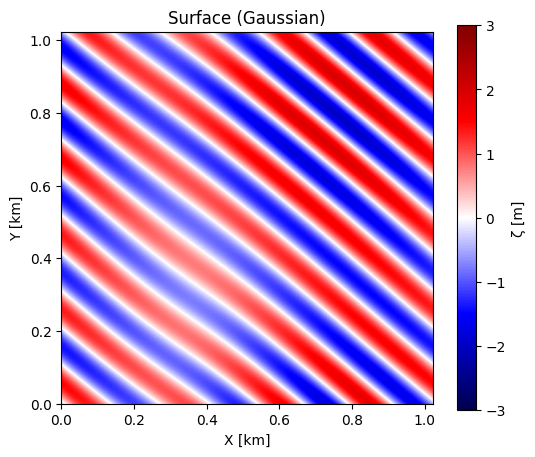

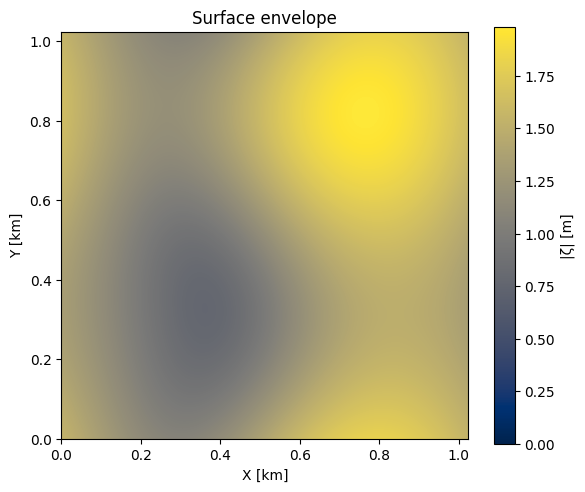

In [3]:
diag_gauss = run_case(typeSpec="Gaussian", **params, do_plot=True)

#### Run Pierson-Moskowitz case

σ = 0.972 m,  max|ζ| = 3.322 m,  max/σ = 3.42


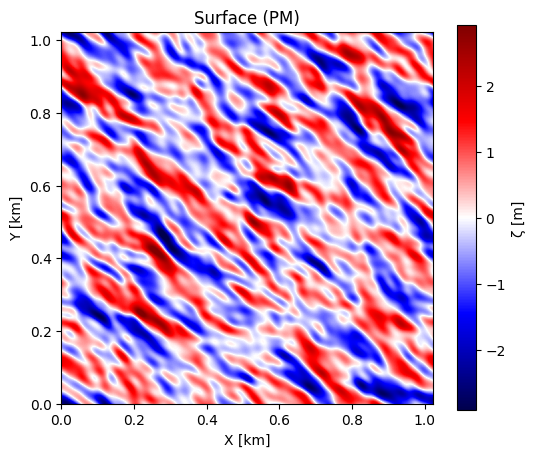

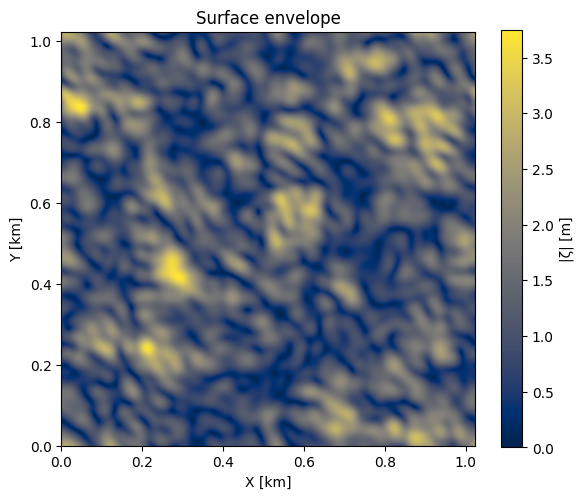

In [4]:
diag_pm = run_case(typeSpec="PM", **params, do_plot=True)

In [5]:
# Show table
df = pd.DataFrame([diag_gauss, diag_pm])
pd.set_option('display.precision', 0)
display(df) 

,Spectrum,"Grid (nx,ny)","Spacing (dx,dy) [m]",Hs(spectrum) [m],Hs(field) [m],Ratio field/spec,Z2D,kX,kY,dkx,dky,X,Y,S2D_r,S2D_i
0,Gaussian,2048×2048,"0.5,0.5",4,4,1e+00,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[-6.283185307179586, -6.277049384028044, -6.2...","[[-6.283185307179586, -6.283185307179586, -6.2...",6e-03,6e-03,"[0.0, 0.5000000000000198, 1.0000000000000395, ...","[0.0, 0.5000000000000198, 1.0000000000000395, ...","[[-0.4132810120222858, -0.39411053495197834, -...","[[-1.4880452457452358, -1.49220707880779, -1.4..."
1,PM,2048×2048,"0.5,0.5",4,4,1e+00,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[-6.283185307179586, -6.277049384028044, -6.2...","[[-6.283185307179586, -6.283185307179586, -6.2...",6e-03,6e-03,"[0.0, 0.5000000000000198, 1.0000000000000395, ...","[0.0, 0.5000000000000198, 1.0000000000000395, ...","[[-2.101798402147684, -2.1372623367499526, -2....","[[1.408276090846491, 1.3851332059791932, 1.360..."


In [6]:
# kX, kY : grid of wavenumbers = 2 * pi /wavelength
# steps : dkx and dky, with nx and ny values. dkx = 2*pi/(dx*nx)
# x, y : grid of real x,y : nx values with a dx step. 

noise = 0

## ---  Sea Surface Grid
x_grid_points = 2048; y_grid_points = 2048   # Grid points in x and y directions [count]
x_spacing = 4; y_spacing = 4       # Grid spacing in x and y directions [m]

## --- Spectrum Definition 
mean_direction_degrees = 60                 # Mean direction of the wave spectrum [degrees]
local_depth = 100                           # Local water depth [m]
wave_period = 10                            # Wave period [s]
significant_wave_height = 4                 # Significant wave height [m]
wavelength = 9.81/np.pi*wave_period**2;     # Wavelength assuming deep water 
wavenumber = 2*np.pi/wavelength;            # Wavenumber, k [1/m]

sx=wavenumber*0.1; sy=sx;

Z2D_def, kX, kY, dkx, dky = def_spectrum_for_surface(
    # Define the spectrum grid 
    nx = x_grid_points, ny = y_grid_points,
    dx = x_spacing, dy = y_spacing,
    # Define the wave spectrum
    theta_m = mean_direction_degrees,
    h = local_depth,
    T0 = wave_period,
    Hs = significant_wave_height,
    sk_theta = sx, sk_k=sy,
    typeSpec = 'Gaussian',  # 'PM' for Pierson-Moskowitz, 'Gaussian' for Gaussian spectrum
    verbose = True,  # Print diagnostic messages
)

Gaussian spectrum selected. Available options:
 - Hs, sk_theta, sk_k.
 With (sk_k, sk_theta) the sigma values for the k-axis along the main direction and
 perpendicular to it respectively.
 Other options (common to all spectrum types): nx, ny, dx, dy, T0, theta_m, h
Hs for Gaussian :  3.999999999999998


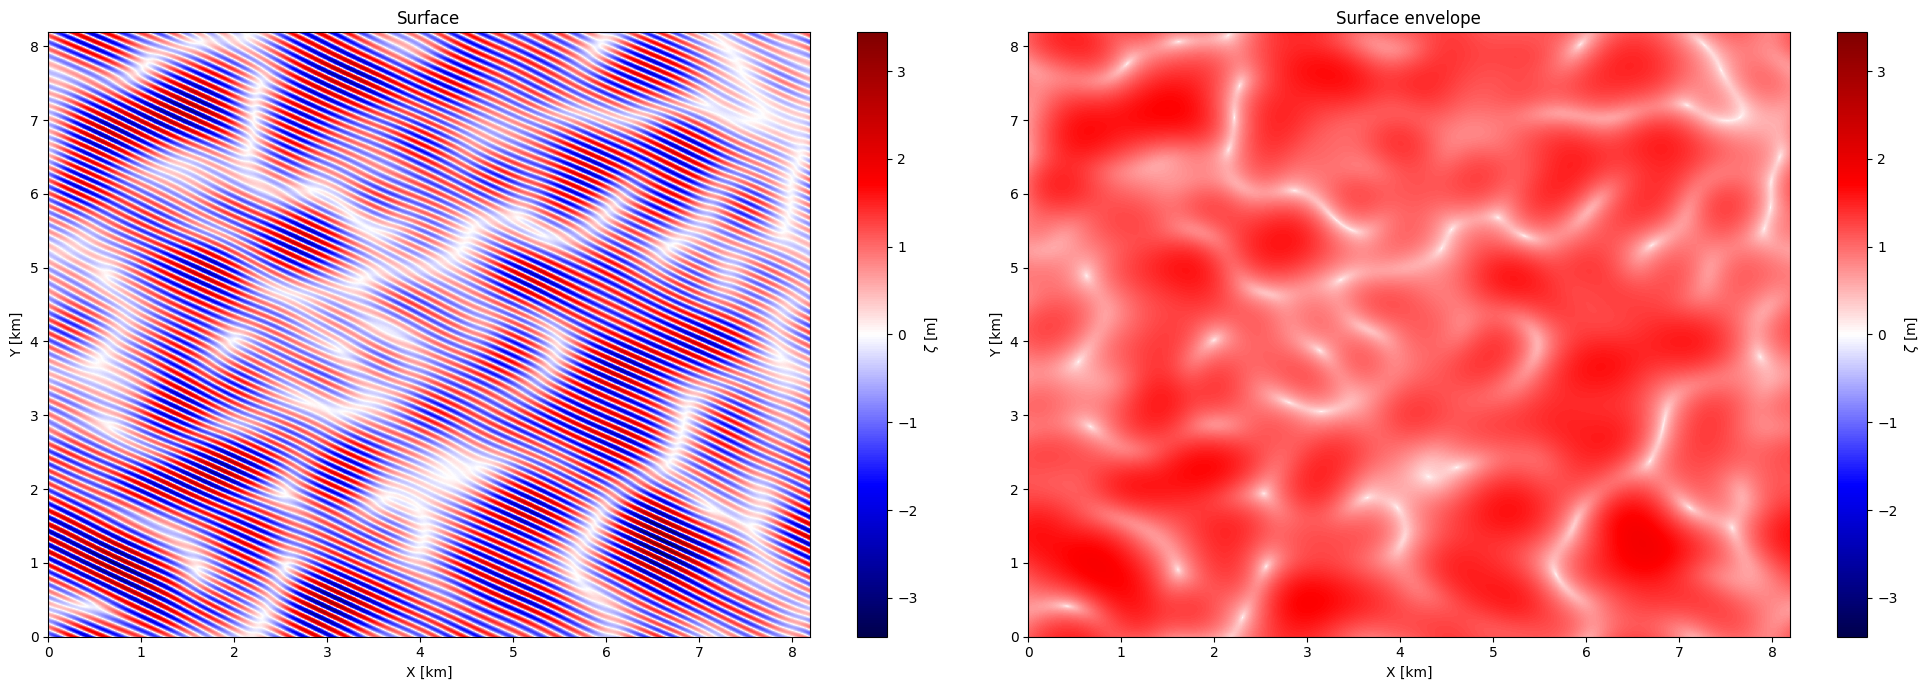

In [7]:
S2D_r, S2D_i, X, Y, kx, rg, dkx, dky = surface_from_Z1kxky_uniform_phase(Z2D_def, kX, kY, 10) 

## Figure Surface et Surface Envelope 
fig,axs=plt.subplots(1,2,figsize=(20,7))        #,sharey=True,sharex=True)

im=axs[0].pcolormesh(X/1000,Y/1000,S2D_r,cmap='seismic',norm = mcolors.Normalize(vmin=S2D_r.min(), vmax=S2D_r.max()))
_=plt.colorbar(im,ax=axs[0],label=r'$\zeta$ [m]')
_=axs[0].set_xlabel(r'X [km]')
_=axs[0].set_ylabel(r'Y [km]')
_=axs[0].set_title(r'Surface')


A = np.sqrt(S2D_r**2+S2D_i**2)
B = np.sqrt(A)

im=axs[1].pcolormesh(X/1000,Y/1000,B,cmap='seismic',norm = mcolors.Normalize(vmin=S2D_r.min(), vmax=S2D_r.max()))
_=plt.colorbar(im,ax=axs[1],label=r'$\zeta$ [m]')

_=axs[1].set_xlabel(r'X [km]')
_=axs[1].set_ylabel(r'Y [km]')
_=axs[1].set_title('Surface envelope')
_=plt.tight_layout()